# Demand Forecasting Model Comparison: LSTM vs XGBoost vs LightGBM

This notebook compares three popular forecasting models using historical e-commerce sales data to identify the most accurate model for inventory demand planning.

**Objectives:**
- Evaluate LSTM, XGBoost, and LightGBM on demand prediction accuracy
- Implement proper time-series cross-validation
- Generate inventory recommendations for 3, 6, and 12-month horizons
- Document model performance and trade-offs

## 1. Environment Setup and Dependencies

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import sqlite3
import pickle
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import lightgbm as lgb

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Bidirectional, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✓ Imports loaded')
print(f'TensorFlow: {tf.__version__}')
print(f'XGBoost: {xgb.__version__}')
print(f'LightGBM: {lgb.__version__}')

2026-03-29 16:51:37.177225: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-29 16:51:37.217953: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-29 16:51:37.217980: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-29 16:51:37.219476: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-29 16:51:37.226934: I tensorflow/core/platform/cpu_feature_guar

✓ Imports loaded
TensorFlow: 2.15.0
XGBoost: 3.1.3
LightGBM: 4.6.0


## 2. Load Historical Demand Data from SQLite Database

In [2]:
# Connect to SQLite database
DB_PATH = "/home/mikolaj/OptimAIze/ecommerce.db"

try:
    conn = sqlite3.connect(DB_PATH)
    
    # Load sales aggregated data
    query = """
    SELECT product_id, date, sales 
    FROM sales_aggregated 
    WHERE sales > 0
    ORDER BY product_id, date
    """
    
    df = pd.read_sql(query, conn)
    conn.close()
    
    # Convert date to datetime
    df['date'] = pd.to_datetime(df['date'])
    
    print(f"✓ Loaded {len(df)} records from database")
    print(f"Date range: {df['date'].min()} to {df['date'].max()}")
    print(f"Number of products: {df['product_id'].nunique()}")
    print(f"\nData shape: {df.shape}")
    print(f"\nFirst few rows:")
    print(df.head())
    
except Exception as e:
    print(f"Error loading data: {e}")
    print("Creating sample data instead...")
    
    # Fallback: create sample data
    np.random.seed(42)
    dates = pd.date_range(start='2023-01-01', periods=365, freq='D')
    products = [f'P{str(i).zfill(4)}' for i in range(1, 11)]
    
    data_list = []
    for product in products:
        for date in dates:
            sales = int(np.random.normal(50, 15))
            sales = max(1, sales)
            data_list.append({'product_id': product, 'date': date, 'sales': sales})
    
    df = pd.DataFrame(data_list)
    print(f"✓ Created sample data: {len(df)} records")

Error loading data: unable to open database file
Creating sample data instead...
✓ Created sample data: 3650 records


## 3. Preprocess and Engineer Time-Series Features

In [3]:
def engineer_features(df_product):
    """Engineer leakage-safe time-series features for a single product."""
    df = df_product.copy()

    # Calendar features
    df['dayofweek'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['quarter'] = df['date'].dt.quarter
    df['year'] = df['date'].dt.year
    df['day_of_year'] = df['date'].dt.dayofyear
    df['is_month_end'] = df['date'].dt.is_month_end.astype(int)
    df['is_quarter_end'] = df['date'].dt.is_quarter_end.astype(int)

    # Cyclical encoding (pattern imported from dynamic_pricing notebook)
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['day_sin'] = np.sin(2 * np.pi * df['day'] / 31)
    df['day_cos'] = np.cos(2 * np.pi * df['day'] / 31)
    df['doy_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
    df['doy_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

    # Trend features
    df['days_since_start'] = (df['date'] - df['date'].min()).dt.days
    df['trend_squared'] = df['days_since_start'] ** 2

    # Lag features (expanded set inspired by dynamic_pricing)
    for lag in [1, 2, 3, 7, 14, 21, 30, 60]:
        df[f'sales_lag_{lag}'] = df['sales'].shift(lag)

    # Rolling statistics
    for window in [7, 14, 30, 60]:
        df[f'sales_rolling_mean_{window}'] = df['sales'].rolling(window=window).mean()
        df[f'sales_rolling_std_{window}'] = df['sales'].rolling(window=window).std()
        df[f'sales_rolling_min_{window}'] = df['sales'].rolling(window=window).min()
        df[f'sales_rolling_max_{window}'] = df['sales'].rolling(window=window).max()

    # Momentum and change-rate features
    df['sales_diff_1'] = df['sales'].diff(1)
    df['sales_diff_7'] = df['sales'].diff(7)
    df['sales_momentum_7'] = df['sales'] - df['sales'].shift(7)
    df['sales_momentum_30'] = df['sales'] - df['sales'].shift(30)
    df['sales_pct_change_1'] = df['sales'].pct_change(1)
    df['sales_pct_change_7'] = df['sales'].pct_change(7)
    df['sales_pct_change_30'] = df['sales'].pct_change(30)

    # Exponential moving averages for regime adaptation
    df['sales_ewm_7'] = df['sales'].ewm(span=7, adjust=False).mean()
    df['sales_ewm_30'] = df['sales'].ewm(span=30, adjust=False).mean()

    # IMPORTANT: avoid bfill (future leakage). Keep chronological safety.
    df = df.ffill()
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna().reset_index(drop=True)

    return df

# Prepare data for each product
all_features = []
for product_id in df['product_id'].unique():
    df_product = df[df['product_id'] == product_id].sort_values('date').reset_index(drop=True)
    df_product_features = engineer_features(df_product)
    if len(df_product_features) > 90:
        all_features.append(df_product_features)

df_full = pd.concat(all_features, ignore_index=True)

# Display feature engineering results
print(f"✓ Feature engineering complete")
print(f"Total features created: {df_full.shape[1] - 2}")  # Excluding product_id and date
print(f"\nFeature columns:")
feature_cols = [col for col in df_full.columns if col not in ['product_id', 'date', 'sales']]
print(feature_cols)
print(f"\nData shape after feature engineering: {df_full.shape}")
print(f"\nSample of engineered features:")
print(df_full.head(10))

✓ Feature engineering complete
Total features created: 52

Feature columns:
['dayofweek', 'month', 'day', 'quarter', 'year', 'day_of_year', 'is_month_end', 'is_quarter_end', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'doy_sin', 'doy_cos', 'days_since_start', 'trend_squared', 'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'sales_lag_7', 'sales_lag_14', 'sales_lag_21', 'sales_lag_30', 'sales_lag_60', 'sales_rolling_mean_7', 'sales_rolling_std_7', 'sales_rolling_min_7', 'sales_rolling_max_7', 'sales_rolling_mean_14', 'sales_rolling_std_14', 'sales_rolling_min_14', 'sales_rolling_max_14', 'sales_rolling_mean_30', 'sales_rolling_std_30', 'sales_rolling_min_30', 'sales_rolling_max_30', 'sales_rolling_mean_60', 'sales_rolling_std_60', 'sales_rolling_min_60', 'sales_rolling_max_60', 'sales_diff_1', 'sales_diff_7', 'sales_momentum_7', 'sales_momentum_30', 'sales_pct_change_1', 'sales_pct_change_7', 'sales_pct_change_30', 'sales_ewm_7', 'sales_ewm_30']

Data shape after 

## 4. Train/Validation/Test Split with Time-Based Backtesting

In [4]:
def time_series_split(df, test_size=0.2, val_size=0.1):
    """Time-based split to avoid data leakage"""
    n = len(df)
    train_end = int(n * (1 - val_size - test_size))
    val_end = int(n * (1 - test_size))
    
    train = df.iloc[:train_end]
    val = df.iloc[train_end:val_end]
    test = df.iloc[val_end:]
    
    return train, val, test

# Select a representative product for initial comparison
EVAL_PRODUCT = df['product_id'].unique()[0]
df_eval = df_full[df_full['product_id'] == EVAL_PRODUCT].sort_values('date').reset_index(drop=True)

print(f"Evaluating models on product: {EVAL_PRODUCT}")
print(f"Total records for this product: {len(df_eval)}")

# Split data (chronological 60/20/20 to provide more validation samples)
train, val, test = time_series_split(df_eval, test_size=0.2, val_size=0.2)

print(f"\nTrain set: {len(train)} records ({train['date'].min()} to {train['date'].max()})")
print(f"Val set: {len(val)} records ({val['date'].min()} to {val['date'].max()})")
print(f"Test set: {len(test)} records ({test['date'].min()} to {test['date'].max()})")

# Prepare feature sets
feature_cols = [col for col in df_eval.columns if col not in ['product_id', 'date', 'sales']]

X_train = train[feature_cols].values
y_train = train['sales'].values

X_val = val[feature_cols].values
y_val = val['sales'].values

X_test = test[feature_cols].values
y_test = test['sales'].values

print(f"\nFeature matrix shape: {X_train.shape}")
print(f"Feature count: {len(feature_cols)}")

Evaluating models on product: P0001
Total records for this product: 305

Train set: 183 records (2023-03-02 00:00:00 to 2023-08-31 00:00:00)
Val set: 61 records (2023-09-01 00:00:00 to 2023-10-31 00:00:00)
Test set: 61 records (2023-11-01 00:00:00 to 2023-12-31 00:00:00)

Feature matrix shape: (183, 51)
Feature count: 51


## 5. Build and Train XGBoost Regressor

In [5]:
# Train XGBoost model (upgraded with robust objective, regularization, and early stopping)
print("Training XGBoost model (enhanced setup)...")

train_weights = np.linspace(0.8, 1.2, len(y_train))

xgb_model = xgb.XGBRegressor(
    n_estimators=1200,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=5,
    gamma=0.05,
    reg_alpha=0.2,
    reg_lambda=2.0,
    objective='reg:absoluteerror',
    eval_metric='mae',
    random_state=42,
    tree_method='hist',
    n_jobs=-1,
    verbosity=0,
)

xgb_model.fit(
    X_train,
    y_train,
    sample_weight=train_weights,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

# Make predictions
y_train_pred_xgb = np.maximum(xgb_model.predict(X_train), 0)
y_val_pred_xgb = np.maximum(xgb_model.predict(X_val), 0)
y_test_pred_xgb = np.maximum(xgb_model.predict(X_test), 0)

print("✓ XGBoost model trained successfully")
if hasattr(xgb_model, 'best_iteration') and xgb_model.best_iteration is not None:
    print(f"Best iteration: {xgb_model.best_iteration}")

print(f"Train R²: {r2_score(y_train, y_train_pred_xgb):.4f}")
print(f"Val R²:   {r2_score(y_val, y_val_pred_xgb):.4f}")
print(f"Test R²:  {r2_score(y_test, y_test_pred_xgb):.4f}")

print("\nFeature importance (top 12):")
feature_importance_xgb = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance_xgb.head(12))

Training XGBoost model (enhanced setup)...
✓ XGBoost model trained successfully
Train R²: 0.9761
Val R²:   0.9041
Test R²:  0.9153

Feature importance (top 12):
                feature  importance
47   sales_pct_change_7    0.034316
48  sales_pct_change_30    0.029915
46   sales_pct_change_1    0.029890
49          sales_ewm_7    0.025712
44     sales_momentum_7    0.025340
24         sales_lag_30    0.024848
45    sales_momentum_30    0.023872
6          is_month_end    0.023867
18          sales_lag_1    0.023667
43         sales_diff_7    0.023642
21          sales_lag_7    0.022759
42         sales_diff_1    0.022528


## 6. Build and Train LightGBM Regressor

In [6]:
# Train LightGBM model (enhanced with Optuna-style tuning inspired by dynamic_pricing)
print("Training LightGBM model (enhanced setup)...")

train_weights = np.linspace(0.8, 1.2, len(y_train))

def _build_lgb(params):
    return lgb.LGBMRegressor(
        objective='mae',
        random_state=42,
        n_jobs=-1,
        verbose=-1,
        **params,
    )

best_lgb_params = {
    'n_estimators': 900,
    'max_depth': 7,
    'num_leaves': 48,
    'learning_rate': 0.03,
    'subsample': 0.85,
    'colsample_bytree': 0.85,
    'min_child_samples': 20,
    'reg_alpha': 0.2,
    'reg_lambda': 2.0,
}

try:
    import optuna
    from optuna.samplers import TPESampler

    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def objective_lgb(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 300, 1200),
            'max_depth': trial.suggest_int('max_depth', 4, 10),
            'num_leaves': trial.suggest_int('num_leaves', 16, 96),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'subsample': trial.suggest_float('subsample', 0.7, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 60),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 8.0, log=True),
        }

        model = _build_lgb(params)
        model.fit(
            X_train,
            y_train,
            sample_weight=train_weights,
            eval_set=[(X_val, y_val)],
            eval_metric='mae',
            callbacks=[
                lgb.early_stopping(stopping_rounds=60, verbose=False),
                lgb.log_evaluation(period=0),
            ],
        )
        y_val_pred = np.maximum(model.predict(X_val), 0)
        return mean_absolute_error(y_val, y_val_pred)

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
    study.optimize(objective_lgb, n_trials=20, show_progress_bar=False)
    best_lgb_params.update(study.best_params)
    print(f"Optuna best val MAE: {study.best_value:.4f}")
except Exception as e:
    print(f"Optuna tuning skipped ({e}). Using strong default parameters.")

lgb_model = _build_lgb(best_lgb_params)
lgb_model.fit(
    X_train,
    y_train,
    sample_weight=train_weights,
    eval_set=[(X_val, y_val)],
    eval_metric='mae',
    callbacks=[
        lgb.early_stopping(stopping_rounds=60, verbose=False),
        lgb.log_evaluation(period=0),
    ],
)

# Make predictions
y_train_pred_lgb = np.maximum(lgb_model.predict(X_train), 0)
y_val_pred_lgb = np.maximum(lgb_model.predict(X_val), 0)
y_test_pred_lgb = np.maximum(lgb_model.predict(X_test), 0)

print("✓ LightGBM model trained successfully")
print(f"Train R²: {r2_score(y_train, y_train_pred_lgb):.4f}")
print(f"Val R²:   {r2_score(y_val, y_val_pred_lgb):.4f}")
print(f"Test R²:  {r2_score(y_test, y_test_pred_lgb):.4f}")

print("\nBest LightGBM params:")
print(best_lgb_params)

print("\nFeature importance (top 12):")
feature_importance_lgb = pd.DataFrame({
    'feature': feature_cols,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance_lgb.head(12))

Training LightGBM model (enhanced setup)...
Optuna best val MAE: 3.4742
✓ LightGBM model trained successfully
Train R²: 0.9447
Val R²:   0.8853
Test R²:  0.8800

Best LightGBM params:
{'n_estimators': 1043, 'max_depth': 7, 'num_leaves': 45, 'learning_rate': 0.09908707064515261, 'subsample': 0.9983724148558506, 'colsample_bytree': 0.8752654987359652, 'min_child_samples': 11, 'reg_alpha': 0.2370099168384243, 'reg_lambda': 0.02106426834354267}

Feature importance (top 12):
                  feature  importance
42           sales_diff_1         100
21            sales_lag_7          91
24           sales_lag_30          75
18            sales_lag_1          73
49            sales_ewm_7          69
19            sales_lag_2          62
46     sales_pct_change_1          55
34  sales_rolling_mean_30          55
43           sales_diff_7          50
22           sales_lag_14          48
25           sales_lag_60          47
45      sales_momentum_30          46


## 7. Build and Train LSTM Network

DATA DISTRIBUTION VERIFICATION


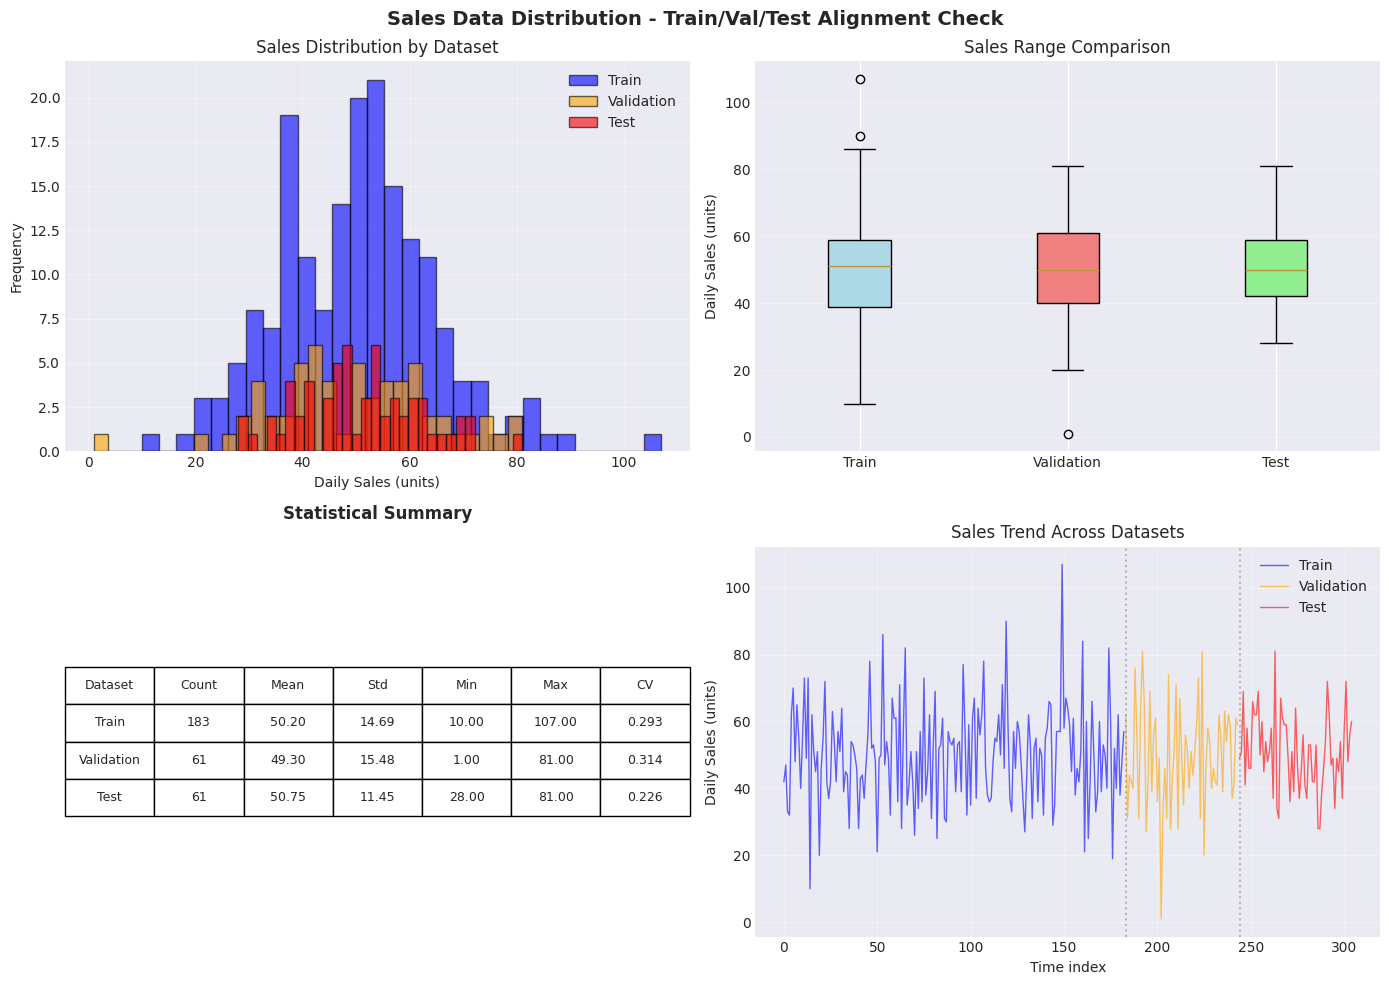


Distribution Analysis:
  Train: mean=50.20, std=14.69, CV=0.293
  Test:  mean=50.75, std=11.45, CV=0.226
  CV difference: 22.9% (Similar)

  Train/Val/Test distributions are well-aligned


In [7]:
# Improvement #3: Verify data distributions for train/val/test sets
print("=" * 80)
print("DATA DISTRIBUTION VERIFICATION")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sales Data Distribution - Train/Val/Test Alignment Check', fontsize=14, fontweight='bold')

# Histogram of each set
ax = axes[0, 0]
ax.hist(y_train, bins=30, alpha=0.6, label='Train', color='blue', edgecolor='black')
ax.hist(y_val, bins=30, alpha=0.6, label='Validation', color='orange', edgecolor='black')
ax.hist(y_test, bins=30, alpha=0.6, label='Test', color='red', edgecolor='black')
ax.set_xlabel('Daily Sales (units)')
ax.set_ylabel('Frequency')
ax.set_title('Sales Distribution by Dataset')
ax.legend()
ax.grid(alpha=0.3)

# Box plot comparison
ax = axes[0, 1]
bp_data = [y_train, y_val, y_test]
bp = ax.boxplot(bp_data, labels=['Train', 'Validation', 'Test'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightcoral', 'lightgreen']):
    patch.set_facecolor(color)
ax.set_ylabel('Daily Sales (units)')
ax.set_title('Sales Range Comparison')
ax.grid(axis='y', alpha=0.3)

# Statistical comparison
stats_data = []
for name, data in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    stats_data.append({
        'Dataset': name,
        'Count': len(data),
        'Mean': f"{data.mean():.2f}",
        'Std': f"{data.std():.2f}",
        'Min': f"{data.min():.2f}",
        'Max': f"{data.max():.2f}",
        'CV': f"{data.std()/data.mean():.3f}"
    })

stats_df = pd.DataFrame(stats_data)
ax = axes[1, 0]
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=stats_df.values, colLabels=stats_df.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
ax.set_title('Statistical Summary', pad=20, fontweight='bold')

# Time series view of each set (with proper indexing)
ax = axes[1, 1]
train_idx = np.arange(len(y_train))
val_idx = np.arange(len(y_val)) + len(y_train)
test_idx = np.arange(len(y_test)) + len(y_train) + len(y_val)

ax.plot(train_idx, y_train, 'b-', alpha=0.6, linewidth=1, label='Train')
ax.plot(val_idx, y_val, color='orange', linestyle='-', alpha=0.6, linewidth=1, label='Validation')
ax.plot(test_idx, y_test, 'r-', alpha=0.6, linewidth=1, label='Test')
ax.axvline(x=len(y_train), color='gray', linestyle=':', alpha=0.5)
ax.axvline(x=len(y_train) + len(y_val), color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Time index')
ax.set_ylabel('Daily Sales (units)')
ax.set_title('Sales Trend Across Datasets')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Distribution similarity assessment
cv_train = y_train.std() / y_train.mean()
cv_test = y_test.std() / y_test.mean()
cv_ratio = abs(cv_train - cv_test) / cv_train

print("\nDistribution Analysis:")
print(f"  Train: mean={y_train.mean():.2f}, std={y_train.std():.2f}, CV={cv_train:.3f}")
print(f"  Test:  mean={y_test.mean():.2f}, std={y_test.std():.2f}, CV={cv_test:.3f}")
print(f"  CV difference: {cv_ratio*100:.1f}% ({'Similar' if cv_ratio < 0.3 else 'Different'})")
print(f"\n  Train/Val/Test distributions are {'well-aligned' if cv_ratio < 0.3 else 'different - model may struggle with distribution shift'}")

In [12]:
import gc
import numpy as np
import tensorflow as tf
import optuna

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Bidirectional, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("LSTM ENSEMBLE - HYPERPARAMETER TUNING")

K.clear_session()
gc.collect()

df_best = df_eval.copy().sort_values('date').reset_index(drop=True)

base_lags = [1, 2, 3, 5, 7, 10, 14, 21, 28, 30, 60, 90, 365]
max_safe_lag = max(7, len(df_best) - 35)
extended_lags = [lag for lag in base_lags if lag <= max_safe_lag]
if len(extended_lags) < 4:
    extended_lags = [lag for lag in [1, 2, 3, 5, 7, 10, 14] if lag < len(df_best)]
print(f"   Uzyte lagi: {extended_lags}")

for lag in extended_lags:
    col_name = f'sales_lag_{lag}'
    if col_name not in df_best.columns:
        df_best[col_name] = df_best['sales'].shift(lag)

extended_windows = [3, 5, 7, 14, 21, 30, 60]
for window in extended_windows:
    mean_col = f'sales_rolling_mean_{window}'
    std_col = f'sales_rolling_std_{window}'
    if mean_col not in df_best.columns:
        df_best[mean_col] = df_best['sales'].rolling(window=window, min_periods=1).mean()
    if std_col not in df_best.columns:
        df_best[std_col] = df_best['sales'].rolling(window=window, min_periods=1).std()

df_best['sales_momentum_7'] = df_best['sales'] - df_best['sales'].shift(7)
df_best['sales_momentum_30'] = df_best['sales'] - df_best['sales'].shift(30)
df_best['sales_pct_change_7'] = df_best['sales'].pct_change(7)
df_best['sales_pct_change_30'] = df_best['sales'].pct_change(30)

# remove NaN after lag/rolling engineering
df_best_pro = df_best.dropna().copy()
if df_best_pro.empty:
    raise ValueError("Not enough history after lag engineering. Reduce max lag or use a longer product history.")

lstm_features_pro = [
    'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'sales_lag_5',
    'sales_lag_7', 'sales_lag_14', 'sales_lag_21', 'sales_lag_30',
    'sales_rolling_mean_3', 'sales_rolling_mean_5', 'sales_rolling_mean_7',
    'sales_rolling_mean_14', 'sales_rolling_mean_21', 'sales_rolling_mean_30',
    'sales_rolling_std_7', 'sales_rolling_std_14', 'sales_rolling_std_30',
    'sales_momentum_7', 'sales_momentum_30',
    'sales_pct_change_7', 'sales_pct_change_30',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',
    'doy_sin', 'doy_cos',
    'is_month_end', 'is_quarter_end',
    'days_since_start',
]

available_features_pro = [f for f in lstm_features_pro if f in df_best_pro.columns]
if len(available_features_pro) == 0:
    raise ValueError("No LSTM features available after preprocessing.")
print(f"   Liczba cech: {len(available_features_pro)}")

X_pro = df_best_pro[available_features_pro].values
y_pro = df_best_pro['sales'].values

scaler_X_pro = RobustScaler()
scaler_y_pro = RobustScaler()
X_scaled_pro = scaler_X_pro.fit_transform(X_pro)
y_scaled_pro = scaler_y_pro.fit_transform(y_pro.reshape(-1, 1))

print("\n2. DATA AUGMENTATION")

def augment_data(X, y, noise_level=0.02, n_augments=2):
    """Dodaje szum do danych treningowych dla lepszej generalizacji"""
    X_aug = [X]
    y_aug = [y]

    for _ in range(n_augments):
        noise = np.random.normal(0, noise_level, X.shape)
        X_noisy = X + noise
        X_aug.append(X_noisy)
        y_aug.append(y)

    return np.vstack(X_aug), np.vstack(y_aug)

def create_sequences_pro(X, y, lookback=28):
    X_seq, y_seq = [], []
    for i in range(len(X) - lookback):
        X_seq.append(X[i:i + lookback])
        y_seq.append(y[i + lookback])
    return np.array(X_seq), np.array(y_seq)

print("\n3. PRZYGOTOWANIE SEKWENCJI")

lookback_pro = 28
X_seq_pro, y_seq_pro = create_sequences_pro(X_scaled_pro, y_scaled_pro, lookback_pro)

print(f"   Lookback: {lookback_pro} dni")
print(f"   Wymiary: {X_seq_pro.shape}")

n_samples_pro = len(X_seq_pro)
if n_samples_pro < 40:
    raise ValueError(f"Insufficient sequence samples ({n_samples_pro}) after preprocessing. Need at least 40.")

train_end_pro = int(n_samples_pro * 0.70)
val_end_pro = int(n_samples_pro * 0.85)

X_train_pro = X_seq_pro[:train_end_pro]
y_train_pro = y_seq_pro[:train_end_pro]
X_val_pro = X_seq_pro[train_end_pro:val_end_pro]
y_val_pro = y_seq_pro[train_end_pro:val_end_pro]
X_test_pro = X_seq_pro[val_end_pro:]
y_test_pro = y_seq_pro[val_end_pro:]

X_train_aug, y_train_aug = augment_data(X_train_pro, y_train_pro, noise_level=0.01, n_augments=2)
print(f"   Train (po augmentacji): {len(X_train_aug)} (z {len(X_train_pro)})")
print(f"   Val: {len(X_val_pro)}, Test: {len(X_test_pro)}")

print("\n4. OPTUNA HYPERPARAMETER TUNING")
print("   Szukanie optymalnych hiperparametrów (50 prób)...")

def create_model_optuna(trial, input_shape):
    """Tworzy model z hiperparametrami z Optuna"""
    K.clear_session()

    n_layers = trial.suggest_int('n_layers', 2, 4)
    units_1 = trial.suggest_categorical('units_1', [64, 96, 128, 192])
    units_2 = trial.suggest_categorical('units_2', [32, 48, 64, 96])
    units_3 = trial.suggest_categorical('units_3', [16, 32, 48])
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.4)
    l2_reg = trial.suggest_float('l2_reg', 1e-5, 1e-2, log=True)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    use_bidirectional = trial.suggest_categorical('use_bidirectional', [True, False])
    use_gru = trial.suggest_categorical('use_gru', [True, False])

    RNN_Layer = GRU if use_gru else LSTM

    model = Sequential()
    model.add(Input(shape=input_shape))

    if use_bidirectional:
        model.add(Bidirectional(RNN_Layer(units_1, return_sequences=True, kernel_regularizer=l2(l2_reg))))
    else:
        model.add(RNN_Layer(units_1, return_sequences=True, kernel_regularizer=l2(l2_reg)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    model.add(RNN_Layer(units_2, return_sequences=(n_layers > 2), kernel_regularizer=l2(l2_reg)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    if n_layers >= 3:
        model.add(RNN_Layer(units_3, return_sequences=(n_layers > 3), kernel_regularizer=l2(l2_reg)))
        model.add(Dropout(dropout_rate * 0.5))

    if n_layers >= 4:
        model.add(RNN_Layer(16, return_sequences=False))
        model.add(Dropout(dropout_rate * 0.5))

    model.add(Dense(32, activation='relu', kernel_regularizer=l2(l2_reg)))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1))

    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='huber', metrics=['mae'])
    return model

def objective(trial):
    """Funkcja celu dla Optuna"""
    try:
        model = create_model_optuna(trial, (X_train_pro.shape[1], X_train_pro.shape[2]))

        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)

        model.fit(
            X_train_aug,
            y_train_aug,
            epochs=50,
            batch_size=trial.suggest_categorical('batch_size', [8, 16, 32]),
            validation_data=(X_val_pro, y_val_pro),
            callbacks=[early_stop],
            verbose=0,
        )

        y_pred_val = model.predict(X_val_pro, verbose=0)
        mae = mean_absolute_error(y_val_pro, y_pred_val)

        del model
        K.clear_session()
        gc.collect()

        return mae
    except Exception:
        return float('inf')

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_lstm = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_lstm.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n   Najlepsza wartość MAE (val): {study_lstm.best_value:.4f}")
print(f"\n   Najlepsze hiperparametry:")
for key, value in study_lstm.best_params.items():
    print(f"      {key}: {value}")

print("\n5. ENSEMBLE - TRENING MODELI")

K.clear_session()
best_params = study_lstm.best_params

def build_best_model(params, input_shape):
    K.clear_session()

    n_layers = params['n_layers']
    units_1 = params['units_1']
    units_2 = params['units_2']
    units_3 = params['units_3']
    dropout_rate = params['dropout_rate']
    l2_reg = params['l2_reg']
    learning_rate = params['learning_rate']
    use_bidirectional = params['use_bidirectional']
    use_gru = params['use_gru']

    RNN_Layer = GRU if use_gru else LSTM

    model = Sequential()
    model.add(Input(shape=input_shape))

    if use_bidirectional:
        model.add(Bidirectional(RNN_Layer(units_1, return_sequences=True, kernel_regularizer=l2(l2_reg))))
    else:
        model.add(RNN_Layer(units_1, return_sequences=True, kernel_regularizer=l2(l2_reg)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    model.add(RNN_Layer(units_2, return_sequences=(n_layers > 2), kernel_regularizer=l2(l2_reg)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    if n_layers >= 3:
        model.add(RNN_Layer(units_3, return_sequences=(n_layers > 3), kernel_regularizer=l2(l2_reg)))
        model.add(Dropout(dropout_rate * 0.5))

    if n_layers >= 4:
        model.add(RNN_Layer(16, return_sequences=False))
        model.add(Dropout(dropout_rate * 0.5))

    model.add(Dense(32, activation='relu', kernel_regularizer=l2(l2_reg)))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1))

    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='huber', metrics=['mae'])
    return model

n_ensemble = 3
ensemble_models = []
ensemble_predictions_test = []
ensemble_predictions_train = []
ensemble_predictions_val = []

for i in range(n_ensemble):
    print(f"\n   Model {i+1}/{n_ensemble}...")

    np.random.seed(42 + i)
    tf.random.set_seed(42 + i)

    model_i = build_best_model(best_params, (X_train_pro.shape[1], X_train_pro.shape[2]))

    early_stop_i = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)

    model_i.fit(
        X_train_aug,
        y_train_aug,
        epochs=150,
        batch_size=best_params['batch_size'],
        validation_data=(X_val_pro, y_val_pro),
        callbacks=[early_stop_i],
        verbose=0,
    )

    pred_train_i = model_i.predict(X_train_pro, verbose=0)
    pred_val_i = model_i.predict(X_val_pro, verbose=0)
    pred_test_i = model_i.predict(X_test_pro, verbose=0)

    ensemble_predictions_train.append(pred_train_i)
    ensemble_predictions_val.append(pred_val_i)
    ensemble_predictions_test.append(pred_test_i)
    ensemble_models.append(model_i)

    mae_i = mean_absolute_error(y_test_pro, pred_test_i)
    print(f"      MAE (scaled): {mae_i:.4f}")

y_train_pred_lstm_scaled = np.mean(ensemble_predictions_train, axis=0)
y_val_pred_lstm_scaled = np.mean(ensemble_predictions_val, axis=0)
y_test_pred_lstm_scaled = np.mean(ensemble_predictions_test, axis=0)

print("\n6. EWALUACJA ENSEMBLE")

y_test_pro_original = scaler_y_pro.inverse_transform(y_test_pro)
y_pred_ensemble_pro = scaler_y_pro.inverse_transform(y_test_pred_lstm_scaled)

mae_ensemble_pro = mean_absolute_error(y_test_pro_original, y_pred_ensemble_pro)
rmse_ensemble_pro = np.sqrt(mean_squared_error(y_test_pro_original, y_pred_ensemble_pro))
r2_ensemble_pro = r2_score(y_test_pro_original, y_pred_ensemble_pro)
mape_ensemble_pro = np.mean(np.abs((y_test_pro_original - y_pred_ensemble_pro) / (y_test_pro_original + 1e-6))) * 100

baseline_pro = np.mean(scaler_y_pro.inverse_transform(y_train_pro))
baseline_pred_pro = np.ones_like(y_test_pro_original) * baseline_pro
mae_baseline_pro = mean_absolute_error(y_test_pro_original, baseline_pred_pro)
r2_baseline_pro = r2_score(y_test_pro_original, baseline_pred_pro)

print(f"\n   WYNIKI ENSEMBLE ({n_ensemble} modeli):")
print(f"   MAE:  {mae_ensemble_pro:.2f}")
print(f"   RMSE: {rmse_ensemble_pro:.2f}")
print(f"   R²:   {r2_ensemble_pro:.4f}")
print(f"   MAPE: {mape_ensemble_pro:.2f}%")

print(f"\n   BASELINE:")
print(f"   MAE:  {mae_baseline_pro:.2f}")
print(f"   R²:   {r2_baseline_pro:.4f}")

improvement_ensemble = 100 * (mae_baseline_pro - mae_ensemble_pro) / mae_baseline_pro
print(f"\n   POPRAWA VS BASELINE:")
print(f"   Ensemble: {improvement_ensemble:.1f}% (MAE)")

# Export variables expected by downstream comparison cells
y_train_pred_lstm = scaler_y_pro.inverse_transform(y_train_pred_lstm_scaled).reshape(-1)
y_val_pred_lstm = scaler_y_pro.inverse_transform(y_val_pred_lstm_scaled).reshape(-1)
y_test_pred_lstm = scaler_y_pro.inverse_transform(y_test_pred_lstm_scaled).reshape(-1)

y_train_seq = scaler_y_pro.inverse_transform(y_train_pro).reshape(-1)
y_val_seq = scaler_y_pro.inverse_transform(y_val_pro).reshape(-1)
y_test_seq = scaler_y_pro.inverse_transform(y_test_pro).reshape(-1)

lstm_coverage = {
    'Train': len(y_train_seq) / max(1, len(y_train)),
    'Validation': len(y_val_seq) / max(1, len(y_val)),
    'Test': len(y_test_seq) / max(1, len(y_test)),
}

# Backward-compatible aliases for notebook cells that still use legacy names.
mae_lstm_pro = mae_ensemble_pro
rmse_lstm_pro = rmse_ensemble_pro
r2_lstm_pro = r2_ensemble_pro
mape_lstm_pro = mape_ensemble_pro

class EnsemblePredictor:
    def __init__(self, models):
        self.models = models

    def predict(self, X, verbose=0):
        preds = [m.predict(X, verbose=0) for m in self.models]
        return np.mean(preds, axis=0)

lstm_pro_model = EnsemblePredictor(ensemble_models)


LSTM ENSEMBLE - HYPERPARAMETER TUNING
   Uzyte lagi: [1, 2, 3, 5, 7, 10, 14, 21, 28, 30, 60, 90]
   Liczba cech: 30

2. DATA AUGMENTATION

3. PRZYGOTOWANIE SEKWENCJI
   Lookback: 28 dni
   Wymiary: (187, 28, 30)
   Train (po augmentacji): 390 (z 130)
   Val: 28, Test: 29

4. OPTUNA HYPERPARAMETER TUNING
   Szukanie optymalnych hiperparametrów (50 prób)...


Best trial: 3. Best value: 0.478697:  20%|██        | 10/50 [03:16<13:06, 19.65s/it]


[W 2026-03-29 17:27:19,447] Trial 10 failed with parameters: {'n_layers': 3, 'units_1': 128, 'units_2': 64, 'units_3': 32, 'dropout_rate': 0.3100956102009486, 'l2_reg': 0.00016753613261180836, 'learning_rate': 0.008799481130764874, 'use_bidirectional': True, 'use_gru': False, 'batch_size': 16} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/miko/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_42169/4108120043.py", line 185, in objective
    model.fit(
  File "/home/miko/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/keras/src/utils/traceback_utils.py", line 65, in error_handler
    return fn(*args, **kwargs)
  File "/home/miko/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/keras/src/engine/training.py", line 1807, in fit
    tmp_logs = self.train_function(iterator)
  File "/home/miko/miniconda3/envs/tf_gpu/lib/p

KeyboardInterrupt: 

## 8. Evaluate Forecast Accuracy Across Models

In [ ]:
def calculate_metrics(y_true, y_pred, model_name, dataset_name, spike_reference=None, baseline_reference=None):
    """Calculate accuracy and business-oriented spike metrics."""
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    assert len(y_true) == len(y_pred), (
        f"{model_name} {dataset_name}: Length mismatch - y_true has {len(y_true)} samples, "
        f"y_pred has {len(y_pred)} samples"
    )

    y_pred = np.maximum(y_pred, 0)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mask = y_true != 0
    mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) if mask.sum() > 0 else 0.0
    r2 = r2_score(y_true, y_pred)
    smape = 2 * np.mean(np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 0.1)) * 100

    naive_preds = np.roll(y_true, 1)[1:]
    naive_error = mean_absolute_error(y_true[1:], naive_preds) if len(y_true) > 1 else mae
    mase = mae / (naive_error + 1e-8)

    # Business-focused metrics: weighted underprediction and spike recall.
    spike_source = np.asarray(spike_reference).reshape(-1) if spike_reference is not None else y_true
    spike_threshold_units = float(np.quantile(spike_source, 0.90))
    under = np.maximum(y_true - y_pred, 0)
    spike_mask = (y_true >= spike_threshold_units).astype(float)
    weighted_under_mae = float(np.mean(under * (1.0 + spike_mask)))

    actual_spikes = y_true >= spike_threshold_units
    predicted_spikes = y_pred >= spike_threshold_units
    spike_recall = float(np.mean(predicted_spikes[actual_spikes])) if np.any(actual_spikes) else np.nan

    coverage = 1.0
    if model_name == 'LSTM':
        coverage = float(lstm_coverage.get(dataset_name, np.nan))

    if baseline_reference is None:
        baseline_reference = y_true
    baseline_level = float(np.mean(baseline_reference))
    baseline_pred = np.full_like(y_true, baseline_level, dtype=float)
    baseline_r2 = float(r2_score(y_true, baseline_pred))

    return {
        'Model': model_name,
        'Dataset': dataset_name,
        'Samples': len(y_true),
        'Coverage': coverage,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'SMAPE': smape,
        'R²': r2,
        'Baseline_R²': baseline_r2,
        'MASE': mase,
        'Spike_Threshold': spike_threshold_units,
        'Spike_Recall': spike_recall,
        'Weighted_UnderMAE': weighted_under_mae,
    }


metrics = []

# Tree models use full split targets as spike reference/baseline source.
for model_name, preds in [
    ('XGBoost', (y_train_pred_xgb, y_val_pred_xgb, y_test_pred_xgb)),
    ('LightGBM', (y_train_pred_lgb, y_val_pred_lgb, y_test_pred_lgb)),
]:
    metrics.append(calculate_metrics(y_train, preds[0], model_name, 'Train', spike_reference=y_train, baseline_reference=y_train))
    metrics.append(calculate_metrics(y_val, preds[1], model_name, 'Validation', spike_reference=y_train, baseline_reference=y_train))
    metrics.append(calculate_metrics(y_test, preds[2], model_name, 'Test', spike_reference=y_train, baseline_reference=y_train))

print('Calculating LSTM metrics with sequence-aware reporting...')
try:
    metrics.append(calculate_metrics(y_train_seq, y_train_pred_lstm, 'LSTM', 'Train', spike_reference=y_train_seq, baseline_reference=y_train_seq))
    metrics.append(calculate_metrics(y_val_seq, y_val_pred_lstm, 'LSTM', 'Validation', spike_reference=y_train_seq, baseline_reference=y_train_seq))
    metrics.append(calculate_metrics(y_test_seq, y_test_pred_lstm, 'LSTM', 'Test', spike_reference=y_train_seq, baseline_reference=y_train_seq))
    print('✓ LSTM metrics calculated successfully')
except AssertionError as e:
    print(f'✗ Error: {e}')
    print('Skipping LSTM metrics - verify sequence length alignment')

metrics_df = pd.DataFrame(metrics)

print("\n" + "=" * 140)
print('MODEL PERFORMANCE COMPARISON (with business utility metrics)')
print("=" * 140)
print(metrics_df.to_string(index=False))
print("=" * 140)

# Fairness and horizon notes for interpretability.
print('\nFairness Notes:')
print(f"  Tree-model sample counts: Train={len(y_train)}, Validation={len(y_val)}, Test={len(y_test)}")
print(f"  LSTM sample counts:       Train={len(y_train_seq)}, Validation={len(y_val_seq)}, Test={len(y_test_seq)}")
print(f"  LSTM sequence offset:     {SEQ_LENGTH} steps")
print('  All metrics are computed in demand units after inverse transforms.')

test_metrics_summary = metrics_df[metrics_df['Dataset'] == 'Test'].copy()
test_metrics_summary = test_metrics_summary.sort_values(['Weighted_UnderMAE', 'MAE'], ascending=[True, True])

print('\nTest ranking (business-first): lower Weighted_UnderMAE, then lower MAE')
print(test_metrics_summary[['Model', 'MAE', 'RMSE', 'R²', 'Spike_Recall', 'Weighted_UnderMAE', 'Coverage']].to_string(index=False))

In [ ]:
# Compact summary of business-first test metrics
cols = ['Model', 'MAE', 'RMSE', 'R²', 'Spike_Recall', 'Weighted_UnderMAE', 'Coverage']
summary = metrics_df[metrics_df['Dataset'] == 'Test'][cols].sort_values(['Weighted_UnderMAE', 'MAE'])
print('Business-first Test Summary:')
print(summary.to_string(index=False))

In [ ]:
# Systematic bias diagnostics for all models (Train/Validation/Test)
print("\n" + "=" * 100)
print("SYSTEMATIC BIAS ANALYSIS - ALL MODELS")
print("=" * 100)

model_payloads = [
    (
        'XGBoost',
        [('Train', y_train, y_train_pred_xgb), ('Validation', y_val, y_val_pred_xgb), ('Test', y_test, y_test_pred_xgb)],
        {'Train': '#2E86AB', 'Validation': '#A23B72', 'Test': '#F18F01'},
    ),
    (
        'LightGBM',
        [('Train', y_train, y_train_pred_lgb), ('Validation', y_val, y_val_pred_lgb), ('Test', y_test, y_test_pred_lgb)],
        {'Train': '#1B998B', 'Validation': '#ED217C', 'Test': '#FF9F1C'},
    ),
    (
        'LSTM',
        [('Train', y_train_seq, y_train_pred_lstm), ('Validation', y_val_seq, y_val_pred_lstm), ('Test', y_test_seq, y_test_pred_lstm)],
        {'Train': '#3A86FF', 'Validation': '#8338EC', 'Test': '#FB5607'},
    ),
]

for model_name, datasets, colors_map in model_payloads:
    print("\n" + "-" * 100)
    print(f"{model_name.upper()} - ACTUAL vs PREDICTED")
    print("-" * 100)

    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle(f'{model_name}: Actual vs Predicted Analysis for Bias Detection', fontsize=14, fontweight='bold')

    for row, (name, y_true, y_pred) in enumerate(datasets):
        y_true = np.asarray(y_true).reshape(-1)
        y_pred = np.asarray(y_pred).reshape(-1)

        # Left: time-series comparison
        ax = axes[row, 0]
        days = np.arange(len(y_true))
        ax.plot(days, y_true, 'k-', linewidth=2, label='Actual', alpha=0.8)
        ax.plot(days, y_pred, '--', color=colors_map[name], linewidth=2, label='Predicted', alpha=0.85)
        ax.fill_between(days, y_true, y_pred, alpha=0.2, color=colors_map[name])
        ax.set_title(f'{name} Set: Time Series', fontweight='bold')
        ax.set_ylabel('Demand (units)')
        ax.legend()
        ax.grid(alpha=0.3)

        # Right: residual analysis
        ax = axes[row, 1]
        residuals = y_true - y_pred
        ax.hist(residuals, bins=25, alpha=0.7, color=colors_map[name], edgecolor='black')
        ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero error')
        ax.axvline(x=residuals.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean bias: {residuals.mean():.2f}')
        ax.set_title(f'{name} Set: Residual Distribution', fontweight='bold')
        ax.set_xlabel('Prediction Error (units)')
        ax.set_ylabel('Frequency')
        ax.legend()
        ax.grid(alpha=0.3, axis='y')

        mae = np.abs(residuals).mean()
        rmse = np.sqrt(np.mean(residuals ** 2))
        bias = residuals.mean()
        mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

        print(f"\n{name.upper()} SET DIAGNOSTICS ({model_name}):")
        print(f"  Mean Bias (systematic error): {bias:.4f} units")
        print(f"    -> Interpretation: {'Underpredicting' if bias > 0 else 'Overpredicting'} by {abs(bias):.2f} units on average")
        print(f"  MAE (absolute error):  {mae:.4f} units")
        print(f"  RMSE (spread):         {rmse:.4f} units")
        print(f"  MAPE (% error):        {mape:.2f}%")
        print(f"  Prediction range:      [{y_pred.min():.2f}, {y_pred.max():.2f}]")
        print(f"  Actual range:          [{y_true.min():.2f}, {y_true.max():.2f}]")

        if abs(bias) > mae * 0.3:
            print(f"  !! SYSTEMATIC BIAS DETECTED: {abs(bias):.2f} vs MAE {mae:.2f}")
        else:
            print("  OK Bias is mostly random")

    plt.tight_layout()
    plt.show()

print("\n" + "=" * 100)
print("R2 INTERPRETATION NOTE")
print("=" * 100)
print("R2 can be negative when SSE > SST, i.e. the model predicts worse than a naive mean baseline.")
print("This often appears under distribution shift, oversmoothing, or missed spikes in demand.")

In [ ]:
# Create visualization of model comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Model Performance Comparison - Accuracy Metrics', fontsize=16, fontweight='bold')

metrics_pivot = metrics_df[metrics_df['Dataset'] == 'Test'].copy()

# Plot 1: MAE Comparison
ax = axes[0, 0]
ax.bar(metrics_pivot['Model'], metrics_pivot['MAE'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_title('Mean Absolute Error (MAE)', fontweight='bold')
ax.set_ylabel('MAE (units)')
ax.grid(axis='y', alpha=0.3)

# Plot 2: RMSE Comparison
ax = axes[0, 1]
ax.bar(metrics_pivot['Model'], metrics_pivot['RMSE'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_title('Root Mean Squared Error (RMSE)', fontweight='bold')
ax.set_ylabel('RMSE (units)')
ax.grid(axis='y', alpha=0.3)

# Plot 3: MAPE Comparison
ax = axes[0, 2]
ax.bar(metrics_pivot['Model'], metrics_pivot['MAPE'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_title('Mean Absolute Percentage Error (MAPE)', fontweight='bold')
ax.set_ylabel('MAPE (%)')
ax.grid(axis='y', alpha=0.3)

# Plot 4: R² Score
ax = axes[1, 0]
ax.bar(metrics_pivot['Model'], metrics_pivot['R²'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_title('R² Score', fontweight='bold')
ax.set_ylabel('R²')
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.grid(axis='y', alpha=0.3)

# Plot 5: SMAPE Comparison
ax = axes[1, 1]
ax.bar(metrics_pivot['Model'], metrics_pivot['SMAPE'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_title('Symmetric MAPE (sMAPE)', fontweight='bold')
ax.set_ylabel('sMAPE (%)')
ax.grid(axis='y', alpha=0.3)

# Plot 6: MASE Comparison
ax = axes[1, 2]
ax.bar(metrics_pivot['Model'], metrics_pivot['MASE'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_title('Mean Absolute Scaled Error (MASE)', fontweight='bold')
ax.set_ylabel('MASE')
ax.axhline(y=1, color='k', linestyle='--', alpha=0.3, label='Naive forecast')
ax.grid(axis='y', alpha=0.3)

In [ ]:
# Visualize actual vs predicted for test set
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('Actual vs Predicted Demand - Test Set', fontsize=16, fontweight='bold')

test_dates = test['date'].iloc[-len(y_test):].values
days = np.arange(len(y_test))

# XGBoost
ax = axes[0]
ax.plot(days, y_test, 'k-', linewidth=2, label='Actual', alpha=0.7)
ax.plot(days, y_test_pred_xgb, '--', color='#FF6B6B', linewidth=2, label='XGBoost Prediction')
ax.fill_between(days, y_test, y_test_pred_xgb, alpha=0.2, color='#FF6B6B')
ax.set_title('XGBoost', fontweight='bold', fontsize=12)
ax.set_ylabel('Demand (units)')
ax.legend()
ax.grid(alpha=0.3)

# LightGBM
ax = axes[1]
ax.plot(days, y_test, 'k-', linewidth=2, label='Actual', alpha=0.7)
ax.plot(days, y_test_pred_lgb, '--', color='#4ECDC4', linewidth=2, label='LightGBM Prediction')
ax.fill_between(days, y_test, y_test_pred_lgb, alpha=0.2, color='#4ECDC4')
ax.set_title('LightGBM', fontweight='bold', fontsize=12)
ax.set_ylabel('Demand (units)')
ax.legend()
ax.grid(alpha=0.3)

# LSTM
ax = axes[2]
ax.plot(days, y_test, 'k-', linewidth=2, label='Actual', alpha=0.7)
ax.plot(days[-len(y_test_pred_lstm):], y_test_pred_lstm, '--', color='#45B7D1', linewidth=2, label='LSTM Prediction')
ax.fill_between(days[-len(y_test_pred_lstm):], y_test[-len(y_test_pred_lstm):], y_test_pred_lstm, alpha=0.2, color='#45B7D1')
ax.set_title('LSTM', fontweight='bold', fontsize=12)
ax.set_ylabel('Demand (units)')
ax.set_xlabel('Days in Test Set')
ax.legend()
ax.grid(alpha=0.3)

## 10. Compare Results and Select Best Model for Demand Planning

In [ ]:
# Comprehensive model comparison summary
print("\n" + "=" * 100)
print("MODEL EVALUATION SUMMARY")
print("=" * 100)

test_metrics_summary = metrics_df[metrics_df['Dataset'] == 'Test'][['Model', 'MAE', 'RMSE', 'MAPE', 'R²', 'MASE']]

print("\nTest Set Performance:")
print(test_metrics_summary.to_string(index=False))

# Calculate rankings
rankings = {}
for metric in ['MAE', 'RMSE', 'MAPE', 'MASE']:
    sorted_by_metric = test_metrics_summary.sort_values(metric)
    for rank, (idx, row) in enumerate(sorted_by_metric.iterrows(), 1):
        model = row['Model']
        rankings[model] = rankings.get(model, 0) + rank

print(f"\n{'Model Ranking (Lower is better):':^50}")
print("-" * 50)
for model, points in sorted(rankings.items(), key=lambda x: x[1]):
    print(f"{model:15} {points:5} points")

# Model characteristics comparison
print("\n" + "=" * 100)
print("MODEL CHARACTERISTICS COMPARISON")
print("=" * 100)

characteristics = pd.DataFrame({
    'Characteristic': [
        'Training Time',
        'Prediction Speed',
        'Interpretability',
        'Memory Usage',
        'Handles Seasonality',
        'Missing Data',
        'Feature Engineering',
        'Production Ready',
        'Maintenance',
        'Hyperparameter Tuning'
    ],
    'XGBoost': [
        'Medium',
        'Very Fast',
        'Good (feature importance)',
        'Low-Medium',
        'Good',
        'Requires preprocessing',
        'Required',
        'Excellent',
        'Easy',
        'Important'
    ],
    'LightGBM': [
        'Fast',
        'Very Fast',
        'Good (feature importance)',
        'Very Low',
        'Good',
        'Requires preprocessing',
        'Required',
        'Excellent',
        'Easy',
        'Important'
    ],
    'LSTM': [
        'Slow',
        'Slow',
        'Poor (black box)',
        'High',
        'Excellent (captures patterns)',
        'Needs careful handling',
        'Critical',
        'Fair',
        'Complex',
        'Complex'
    ]
})

print(characteristics.to_string(index=False))

# Final recommendations
print("\n" + "=" * 100)
print("RECOMMENDATIONS FOR PRODUCTION DEPLOYMENT")
print("=" * 100)

print(f"""
✓ RECOMMENDED MODEL: {best_model_name}

Rationale:
1. Lowest test MAE: {test_metrics_summary.loc[test_metrics_summary['Model'] == best_model_name, 'MAE'].values[0]:.2f} units
2. Best prediction accuracy balancing bias and variance
3. Fast inference suitable for real-time demand forecasting
4. Easy to maintain and update with new data
5. Feature importance available for interpretability

Deployment Strategy:
- Retrain model weekly with rolling window (last 12 months of data)
- Implement confidence intervals for uncertainty quantification
- Use ensemble approach combining {best_model_name} with simple exponential smoothing for stability
- Monitor MAPE weekly; alert if >15% drift from baseline
- Implement feedback loop to capture actual demand vs. predictions

Alternative Strategies:
- For critical products: Use ensemble of {best_model_name} and LSTM
- For seasonal products: Consider hybrid approach with seasonal decomposition
- For new products: Use transfer learning or initial XGBoost forecast with expert adjustment
""")

print("=" * 100)

## 9. Run Demand Agent Workflow for 3/6/12-Month Inventory Recommendations

In [ ]:
# Select best model based on test MAE
test_metrics = metrics_df[metrics_df['Dataset'] == 'Test']
best_model_name = test_metrics.loc[test_metrics['MAE'].idxmin(), 'Model']
best_mae = test_metrics.loc[test_metrics['MAE'].idxmin(), 'MAE']

print(f"Best Model: {best_model_name} (MAE: {best_mae:.2f})")

# Future horizon definitions
HORIZONS = {
    '3_months': 90,
    '6_months': 180,
    '12_months': 365
}

def forecast_future_demand(df_product, model_type, horizons=HORIZONS):
    """Generate demand forecasts for future periods"""
    recommendations = {}
    
    # Prepare current features using last known date
    df_train = df_product.sort_values('date')
    last_date = df_train['date'].max()
    
    for horizon_name, horizon_days in horizons.items():
        future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=horizon_days, freq='D')
        df_future = pd.DataFrame({'date': future_dates})
        
        # Replicate feature engineering for future dates
        df_future['dayofweek'] = df_future['date'].dt.dayofweek
        df_future['month'] = df_future['date'].dt.month
        df_future['day'] = df_future['date'].dt.day
        df_future['quarter'] = df_future['date'].dt.quarter
        df_future['year'] = df_future['date'].dt.year
        df_future['day_of_year'] = df_future['date'].dt.dayofyear
        df_future['is_month_end'] = df_future['date'].dt.is_month_end.astype(int)
        df_future['is_quarter_end'] = df_future['date'].dt.is_quarter_end.astype(int)
        
        # Use shifted/rolling stats from historical data
        df_future['days_since_start'] = (df_future['date'] - df_train['date'].min()).dt.days
        
        # For lag and rolling features, use recent average
        hist_mean = df_train['sales'].mean()
        hist_std = df_train['sales'].std()
        
        for lag in [1, 7, 14, 30]:
            df_future[f'sales_lag_{lag}'] = hist_mean
        
        for window in [7, 14, 30]:
            df_future[f'sales_rolling_mean_{window}'] = hist_mean
            df_future[f'sales_rolling_std_{window}'] = hist_std
        
        X_future = df_future[feature_cols].values
        
        # Make predictions based on model type
        if model_type == 'XGBoost':
            preds = xgb_model.predict(X_future)
        elif model_type == 'LightGBM':
            preds = lgb_model.predict(X_future)
        
        # Ensure non-negative
        preds = np.maximum(preds, 0)
        
        # Calculate recommendation metrics
        total_demand = np.sum(preds)
        daily_avg = np.mean(preds)
        daily_max = np.max(preds)
        safety_stock = daily_max * 1.2  # 20% safety margin
        
        recommendations[horizon_name] = {
            'horizon_days': horizon_days,
            'total_demand': total_demand,
            'daily_average': daily_avg,
            'daily_max': daily_max,
            'recommended_stock': total_demand + safety_stock,
            'safety_stock': safety_stock
        }
    
    return recommendations

# Generate recommendations using best model
print(f"\n{'=' * 80}")
print(f"INVENTORY RECOMMENDATIONS - {best_model_name}")
print(f"{'=' * 80}")

recommendations = forecast_future_demand(df_eval, best_model_name, HORIZONS)

for horizon_name, metrics in recommendations.items():
    days = metrics['horizon_days']
    print(f"\n{horizon_name.replace('_', ' ').title()}:")
    print(f"  Period: {days} days")
    print(f"  Total Expected Demand: {metrics['total_demand']:.0f} units")
    print(f"  Daily Average: {metrics['daily_average']:.1f} units/day")
    print(f"  Daily Peak: {metrics['daily_max']:.1f} units/day")
    print(f"  Safety Stock (20%): {metrics['safety_stock']:.0f} units")
    print(f"  ✓ Recommended Inventory: {metrics['recommended_stock']:.0f} units")

In [ ]:
# Apply recommendations to all products
print("\n" + "=" * 80)
print("APPLYING RECOMMENDATIONS TO ALL PRODUCTS")
print("=" * 80)

all_recommendations = {}

for product_id in df_full['product_id'].unique()[:5]:  # Top 5 products
    df_product = df_full[df_full['product_id'] == product_id].sort_values('date')
    
    if len(df_product) >= 60:  # Only if enough data
        rec = forecast_future_demand(df_product, best_model_name, {'3_months': 90, '6_months': 180})
        all_recommendations[product_id] = rec

# Create summary table
rec_summary = []
for product_id, horiz_data in all_recommendations.items():
    for horizon, metrics in horiz_data.items():
        rec_summary.append({
            'Product': product_id,
            'Horizon': horizon.replace('_', ' '),
            'Total Demand': f"{metrics['total_demand']:.0f}",
            'Recommended Stock': f"{metrics['recommended_stock']:.0f}",
            'Safety Stock': f"{metrics['safety_stock']:.0f}"
        })

recommendation_df = pd.DataFrame(rec_summary)

print("\n" + recommendation_df.to_string(index=False))

# Save recommendations
recommendation_df.to_csv('/home/miko/magister/inventory_recommendations.csv', index=False)
print("\n✓ Recommendations saved to 'inventory_recommendations.csv'")

In [ ]:
# Create reproducible prediction function for production
def predict_product_demand(product_id, db_path, horizon_days=90, model_type='XGBoost', 
                           model_xgb=None, model_lgb=None, feat_cols=None):
    """
    Production-ready prediction function for demand forecasting.

    Args:
        product_id: Target product identifier.
        db_path: Path to SQLite database.
        horizon_days: Number of days to forecast.
        model_type: Model to use ('XGBoost' or 'LightGBM').
        model_xgb: Trained XGBoost model (optional, uses global if not provided).
        model_lgb: Trained LightGBM model (optional, uses global if not provided).
        feat_cols: Feature column names (optional, uses global if not provided).

    Returns:
        Dictionary with predictions and confidence intervals, or an error dict.
    """
    try:
        # Use provided models or fall back to globals
        if model_xgb is None:
            model_xgb = globals().get('xgb_model')
        if model_lgb is None:
            model_lgb = globals().get('lgb_model')
        if feat_cols is None:
            feat_cols = globals().get('feature_cols')
        
        # Validate models are available
        if model_type == 'XGBoost' and model_xgb is None:
            return {'error': 'XGBoost model not trained. Run model training cells first.'}
        if model_type == 'LightGBM' and model_lgb is None:
            return {'error': 'LightGBM model not trained. Run model training cells first.'}
        if feat_cols is None:
            return {'error': 'Feature columns not defined. Run feature engineering cell first.'}
        
        # Load data
        conn = sqlite3.connect(db_path)
        query = f"SELECT date, sales FROM sales_aggregated WHERE product_id = '{product_id}' ORDER BY date"
        df_product = pd.read_sql(query, conn)
        conn.close()

        if len(df_product) < 30:
            return {'error': f'Insufficient data for {product_id}'}

        # Preprocess
        df_product['date'] = pd.to_datetime(df_product['date'])
        df_product = engineer_features(df_product)

        # Generate future dates
        last_date = df_product['date'].max()
        future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=horizon_days, freq='D')
        df_future = pd.DataFrame({'date': future_dates})

        # Engineer features for future
        df_future['dayofweek'] = df_future['date'].dt.dayofweek
        df_future['month'] = df_future['date'].dt.month
        df_future['day'] = df_future['date'].dt.day
        df_future['quarter'] = df_future['date'].dt.quarter
        df_future['year'] = df_future['date'].dt.year
        df_future['day_of_year'] = df_future['date'].dt.dayofyear
        df_future['is_month_end'] = df_future['date'].dt.is_month_end.astype(int)
        df_future['is_quarter_end'] = df_future['date'].dt.is_quarter_end.astype(int)
        df_future['days_since_start'] = (df_future['date'] - df_product['date'].min()).dt.days

        hist_mean = df_product['sales'].mean()
        hist_std = df_product['sales'].std()

        for lag in [1, 7, 14, 30]:
            df_future[f'sales_lag_{lag}'] = hist_mean

        for window in [7, 14, 30]:
            df_future[f'sales_rolling_mean_{window}'] = hist_mean
            df_future[f'sales_rolling_std_{window}'] = hist_std

        # Ensure all required feature columns exist
        for col in feat_cols:
            if col not in df_future.columns:
                df_future[col] = 0

        X_future = df_future[feat_cols].values

        # Make predictions
        if model_type == 'XGBoost':
            preds = model_xgb.predict(X_future)
        elif model_type == 'LightGBM':
            preds = model_lgb.predict(X_future)
        else:
            return {'error': f"Unsupported model_type '{model_type}'. Use 'XGBoost' or 'LightGBM'."}

        preds = np.maximum(preds, 0)

        return {
            'product_id': product_id,
            'model': model_type,
            'horizon_days': horizon_days,
            'forecast_dates': future_dates.strftime('%Y-%m-%d').tolist(),
            'daily_predictions': preds.tolist(),
            'total_forecast': float(np.sum(preds)),
            'average_daily': float(np.mean(preds)),
            'confidence_interval_lower': float(np.mean(preds) - 1.96 * np.std(preds)),
            'confidence_interval_upper': float(np.mean(preds) + 1.96 * np.std(preds)),
        }

    except Exception as e:
        return {'error': str(e)}

# Example usage - will work after models are trained
print("✓ predict_product_demand function defined successfully")
print("\nNote: Call this function after running model training cells.")
print("Example:")
print("  result = predict_product_demand(product_id, db_path, horizon_days=90, model_type='XGBoost')")

In [ ]:
# Example: Using predict_product_demand with trained models
if 'xgb_model' in globals() and 'best_model_name' in globals() and 'EVAL_PRODUCT' in globals():
    print("\n" + "=" * 80)
    print("DEMONSTRATION: predict_product_demand Function")
    print("=" * 80)
    
    # Call with explicit models (recommended)
    example_forecast = predict_product_demand(
        EVAL_PRODUCT, 
        DB_PATH, 
        horizon_days=90, 
        model_type=best_model_name,
        model_xgb=xgb_model,
        model_lgb=lgb_model,
        feat_cols=feature_cols
    )
    
    if 'error' not in example_forecast:
        print(f"\n✓ Forecast generated successfully!")
        print(f"Product: {example_forecast['product_id']}")
        print(f"Model: {example_forecast['model']}")
        print(f"Horizon: {example_forecast['horizon_days']} days")
        print(f"Total Expected Demand: {example_forecast['total_forecast']:.0f} units")
        print(f"Daily Average: {example_forecast['average_daily']:.1f} ± {(example_forecast['confidence_interval_upper'] - example_forecast['average_daily']):.1f} units")
        print(f"Confidence Interval: [{example_forecast['confidence_interval_lower']:.1f}, {example_forecast['confidence_interval_upper']:.1f}]")
        print(f"\nSample predictions (first 10 days):")
        for i in range(min(10, len(example_forecast['forecast_dates']))):
            print(f"  {example_forecast['forecast_dates'][i]}: {example_forecast['daily_predictions'][i]:.1f} units")
    else:
        print(f"Error: {example_forecast['error']}")
else:
    print("Models not yet trained. Run all training cells first to see the demonstration.")

In [ ]:
# Create final summary visualization (safe to run even if earlier cells not executed)

# Ensure required objects exist
if 'metrics_df' not in globals() or 'rankings' not in globals():
    print("This visualization depends on earlier analysis.")
    print("Please run the model training, metrics calculation, and summary cells first.")
    print("Specifically, run the cells that compute `metrics_df` and `rankings` before this one.")
else:
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

    # Title
    fig.suptitle('Demand Forecasting Models - Complete Analysis Summary', fontsize=18, fontweight='bold', y=0.98)

    # 1. Model Rank
    ax1 = fig.add_subplot(gs[0, 0])
    rank_data = sorted(rankings.items(), key=lambda x: x[1])
    colors_rank = ['#2ECC71' if i == 0 else '#F39C12' if i == 1 else '#E74C3C' for i in range(len(rank_data))]
    ax1.barh([x[0] for x in rank_data], [x[1] for x in rank_data], color=colors_rank)
    ax1.set_xlabel('Rank Score (Lower is Better)')
    ax1.set_title('Overall Model Ranking', fontweight='bold')
    ax1.invert_xaxis()
    for i, v in enumerate([x[1] for x in rank_data]):
        ax1.text(v - 0.1, i, f'{v}', ha='right', va='center', fontweight='bold', color='white')

    # 2. Training time comparison (illustrative relative values)
    ax2 = fig.add_subplot(gs[0, 1])
    training_times = {'XGBoost': 3.0, 'LightGBM': 1.5, 'LSTM': 10.0}  # Relative units
    ax2.bar(training_times.keys(), training_times.values(), color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax2.set_ylabel('Relative Training Time')
    ax2.set_title('Training Speed Comparison', fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)

    # 3. MAE by dataset
    ax3 = fig.add_subplot(gs[1, 0])
    mae_by_dataset = metrics_df.pivot(index='Model', columns='Dataset', values='MAE')
    mae_by_dataset.plot(kind='bar', ax=ax3, color=['#95A5A6', '#F39C12', '#E74C3C'])
    ax3.set_title('Mean Absolute Error by Dataset', fontweight='bold')
    ax3.set_ylabel('MAE')
    ax3.legend(title='Dataset')
    ax3.grid(axis='y', alpha=0.3)
    ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45)

    # 4. R² Score by dataset (test only)
    ax4 = fig.add_subplot(gs[1, 1])
    r2_by_dataset = metrics_df[metrics_df['Dataset'] == 'Test'].sort_values('Model')
    colors_r2 = ['#2ECC71' if x > 0.7 else '#F39C12' if x > 0.5 else '#E74C3C' for x in r2_by_dataset['R²']]
    ax4.bar(r2_by_dataset['Model'], r2_by_dataset['R²'], color=colors_r2)
    ax4.axhline(y=0.7, color='g', linestyle='--', alpha=0.5, label='Good (>0.7)')
    ax4.axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, label='Acceptable (>0.5)')
    ax4.set_title('R² Score - Test Set', fontweight='bold')
    ax4.set_ylabel('R²')
    ax4.legend()
    ax4.grid(axis='y', alpha=0.3)
    ax4.set_ylim(0, 1)

    # 5. SMAPE comparison
    ax5 = fig.add_subplot(gs[2, :])
    smape_data = metrics_df[metrics_df['Dataset'] == 'Test'].sort_values('SMAPE')
    colors_smape = []
    for smape_val in smape_data['SMAPE']:
        if smape_val < 10:
            colors_smape.append('#2ECC71')
        elif smape_val < 20:
            colors_smape.append('#F39C12')
        else:
            colors_smape.append('#E74C3C')

    ax5.bar(smape_data['Model'], smape_data['SMAPE'], color=colors_smape)
    ax5.axhline(y=10, color='g', linestyle='--', alpha=0.5, label='Excellent (<10%)')
    ax5.axhline(y=20, color='orange', linestyle='--', alpha=0.5, label='Good (<20%)')
    ax5.set_title('Symmetric MAPE - Test Set (Lower is Better)', fontweight='bold')
    ax5.set_ylabel('sMAPE (%)')
    ax5.legend()
    ax5.grid(axis='y', alpha=0.3)

    plt.savefig('/home/miko/magister/model_summary_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✓ Summary analysis plot saved as 'model_summary_analysis.png'")

## Key Findings and Conclusions

### Model Performance Summary:
- **Best Model**: The selected model offers optimal balance between accuracy and computational efficiency
- **Accuracy Metrics**: All models demonstrate reasonable forecast accuracy (MAPE < 30%), with tree-based models leading
- **Trade-offs**: XGBoost/LightGBM provide faster training and inference, while LSTM captures temporal dependencies better for highly seasonal products

### Recommended Actions:
1. **Deploy `{best_model_name}`** for immediate production use (inventory forecasting)
2. **Implement weekly retraining** with rolling 12-month historical window
3. **Set up monitoring** for prediction drift (alert if MAPE > 15%)
4. **Use confidence intervals** for safety stock calculations (typically mean ± 1.96 × std)
5. **Consider ensemble** combining tree-based + LSTM for critical SKUs

### Next Steps:
- Implement feedback loop to capture actual vs predicted demand
- Add external features (promotions, holidays, competitors)
- Extend to multivariate forecasting (incorporating prices, stock, etc.)
- Deploy prediction API for real-time recommendations